In [1]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

In [2]:
x = tf.Variable(3.0)
with tf.GradientTape() as tape:
    y = x ** 2

In [3]:
dy_dx = tape.gradient(y, x)
dy_dx.numpy()

np.float32(6.0)

In [4]:
w = tf.Variable(tf.random.normal((3, 2)))
b = tf.Variable(tf.zeros(2, dtype=tf.float32))
x = [[1., 2., 3.]]

with tf.GradientTape(persistent=True) as tape:
    y = x @ w + b
    loss = tf.reduce_mean(y**2)

In [5]:
[dl_dw, dl_db] = tape.gradient(loss, [w, b])

In [6]:
print(w.shape)
print(dl_dw.shape)

(3, 2)
(3, 2)


In [7]:
layer = tf.keras.layers.Dense(2, activation='relu')
x = tf.constant([[1., 2., 3.]])
with tf.GradientTape() as tape:
    y = layer(x)
    loss = tf.reduce_mean(y**2)
grad = tape.gradient(loss, layer.trainable_variables)

In [8]:
for var, g in zip(layer.trainable_variables, grad):
    print(f'{var.name}: {var.shape}')
    print(f'{{g.shape}}')

kernel: (3, 2)
{g.shape}
bias: (2,)
{g.shape}


In [9]:
# A trainable variable
x0 = tf.Variable(3.0, name='x0')
# Not trainable
x1 = tf.Variable(3.0, name='x1', trainable=False)
# Not a variable, a variable + tensor returns a tensor
x2 = tf.Variable(2.0, name='x2') + 2.0
# No es una variable
x3 = tf.constant(3.0, name='x3')

with tf.GradientTape() as tape:
    y = x0**2 + x1**2 + x2**2 + x3**2

grad = tape.gradient(y, [x0, x1, x2, x3])
for g in grad:
    print(g)

tf.Tensor(6.0, shape=(), dtype=float32)
None
None
None


In [10]:
[var.name for var in tape.watched_variables()]

['x0:0']

In [11]:
# to record gradients to a tf.Tensor, you need to call GradientTape.watch
x = tf.constant(3.0)
with tf.GradientTape() as tape:
    tape.watch(x)
    y = x**2
dy_dx = tape.gradient(y, x)
dy_dx.numpy()

np.float32(6.0)

In [12]:
x0 = tf.Variable(.0)
x1 = tf.Variable(10.0)
with tf.GradientTape(watch_accessed_variables=False) as tape:
    tape.watch(x1)
    y0 = tf.math.sin(x0)
    y1 = tf.nn.softplus(x1)
    y = y0 + y1
    ys = tf.reduce_sum(y)

In [13]:
grad = tape.gradient(ys, {'x0': x0, 'x1': x1})
print('dy_dx0', grad['x0'])
print('dy_dx1', grad['x1'].numpy())

dy_dx0 None
dy_dx1 0.9999546


In [14]:
x = tf.constant(3.0)
with tf.GradientTape() as tape:
    tape.watch(x)
    y = x * x
    z = y * y
print(tape.gradient(z, y).numpy())

18.0


In [15]:
x = tf.constant([1, 3.0])
with tf.GradientTape(persistent=True) as tape:
    tape.watch(x)
    y = x * x
    z = y * y
print(tape.gradient(z, x).numpy())
print(tape.gradient(y, x).numpy())

[  4. 108.]
[2. 6.]


In [16]:
del tape

In [18]:
# gradientes de objetivos no escalares
x = tf.Variable(2.0)
with tf.GradientTape(persistent=True) as tape:
    y0 = x ** 2
    y1 = 1 / x
print(tape.gradient(y0, x).numpy())
print(tape.gradient(y1, x).numpy())

4.0
-0.25


In [19]:
x = tf.Variable(2.0)
with tf.GradientTape() as tape:
  y0 = x**2
  y1 = 1 / x

print(tape.gradient({'y0': y0, 'y1': y1}, x).numpy())

3.75


In [20]:
x = tf.Variable(2.)
with tf.GradientTape() as tape:
    y = x * [3., 4.]
print(tape.gradient(y, x).numpy())

7.0


In [22]:
x = tf.linspace(-10.0, 10.0, 201)
with tf.GradientTape() as tape:
    tape.watch(x)
    y = tf.nn.sigmoid(x)
dy_dx = tape.gradient(y, x)

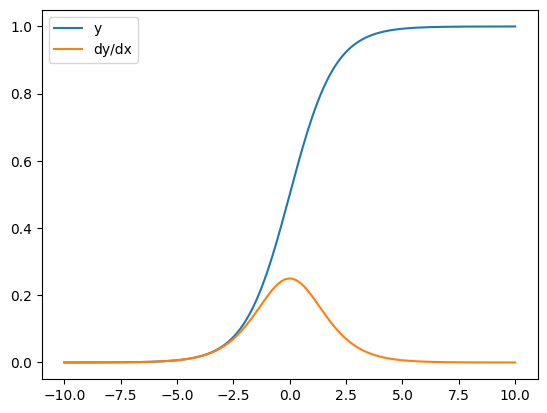

In [24]:
plt.plot(x, y, label='y')
plt.plot(x, dy_dx, label='dy/dx')
plt.legend()
plt.show()